In [107]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

In [108]:
# Initialize detector
detector = cv2.FaceDetectorYN.create("../../models/face_detection_yunet_2023mar.onnx", "", (320, 320))

# Read image
source = cv2.imread('../../images/nazar.jpg')
source = cv2.cvtColor(source, cv2.COLOR_BGR2RGB)
rows, cols, _ = source.shape

# Get image shape
img_W = int(source.shape[1])
img_H = int(source.shape[0])

# Set input size
detector.setInputSize((cols, rows))

# Run detector
faces_src = detector.detect(source)
assert faces_src[0]

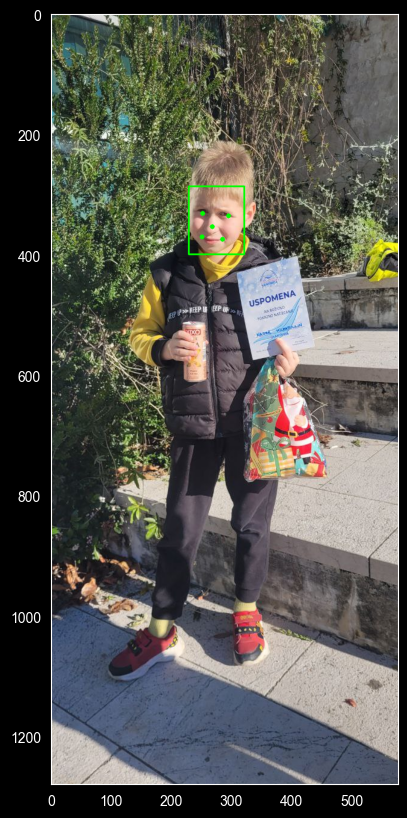

In [109]:
# Show detected faces on image
result = np.copy(source)
faces_src_img = []

for face in faces_src[1]:
    # Draw box
    x1, y1, w, h = face[0:4]
    faces_src_img.append(source[int(y1):int(y1+h), int(x1):int(x1+h), :])
    cv2.rectangle(result, (int(x1), int(y1)), (int(x1+w), int(y1+h)), color=(0, 255, 0), thickness=2)

    # Draw landmarks
    for idx in range(4, len(face)-1, 2):
        cv2.circle(result, (int(face[idx]), int(face[idx+1])), radius=4, color=(0, 255, 0), thickness=-1)

plt.imshow(result)
plt.grid(False)

In [110]:
target = cv2.imread('../../images/nazar_vienna.jpg')
target = cv2.cvtColor(target, cv2.COLOR_BGR2RGB)
rows, cols, _ = target.shape

detector.setInputSize((cols, rows))
faces_dst = detector.detect(target)
assert faces_dst[0]

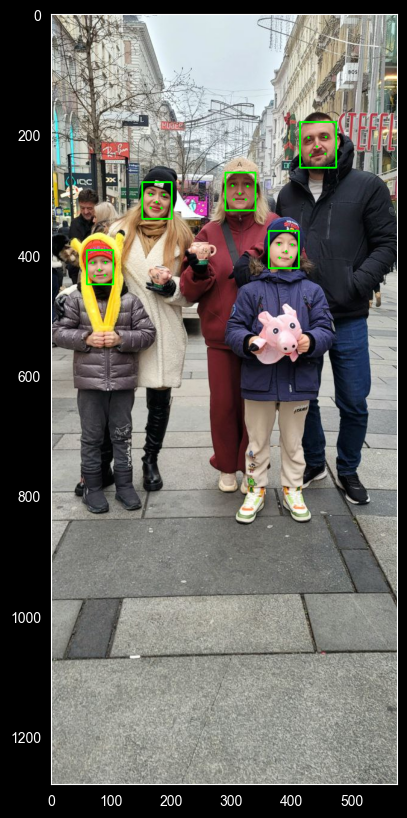

In [111]:
result = np.copy(target)
faces_dst_img = []


for face in faces_dst[1]:
    x1, y1, w, h = face[0:4]
    faces_dst_img.append(target[int(y1):int(y1+h), int(x1):int(x1+h), :])
    cv2.rectangle(result, (int(x1), int(y1)), (int(x1+w), int(y1+h)), color=(0, 255, 0), thickness=2)

    # Draw landmarks
    for idx in range(4, len(face)-1, 2):
        cv2.circle(result, (int(face[idx]), int(face[idx+1])), radius=2, color=(0, 255, 0), thickness=-1)

plt.imshow(result)
plt.grid(False)

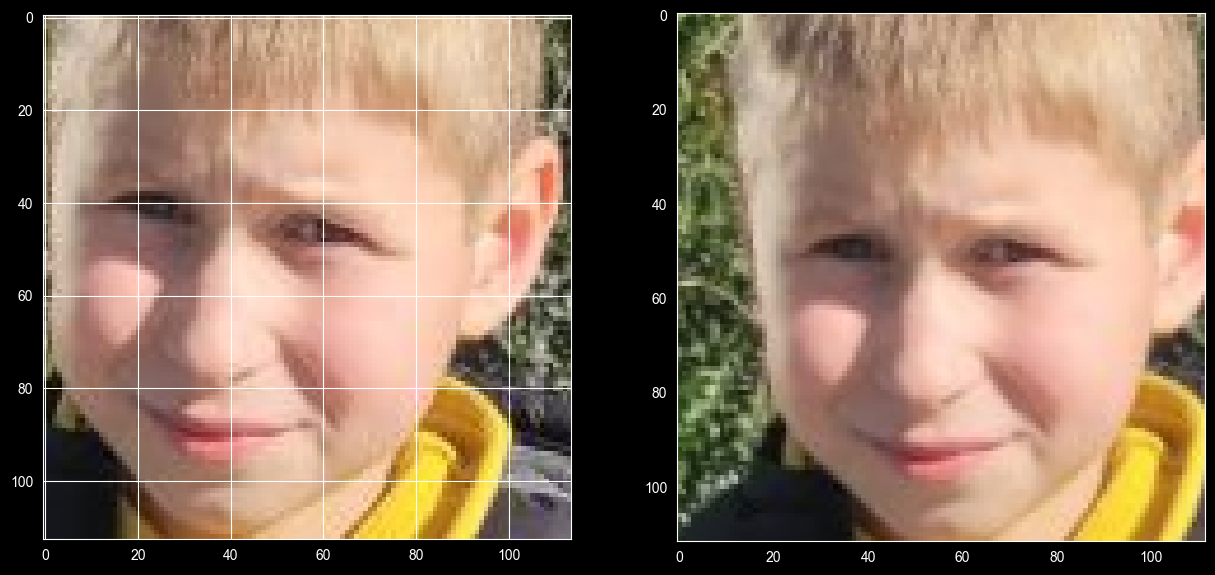

In [112]:
recognizer = cv2.FaceRecognizerSF.create("../../models/face_recognition_sface_2021dec.onnx", "")

# Align source face
faces_src_agn = recognizer.alignCrop(source, faces_src[1][0])

plt.subplot(121), plt.imshow(faces_src_img[0])
plt.subplot(122), plt.imshow(faces_src_agn)
plt.grid(False)

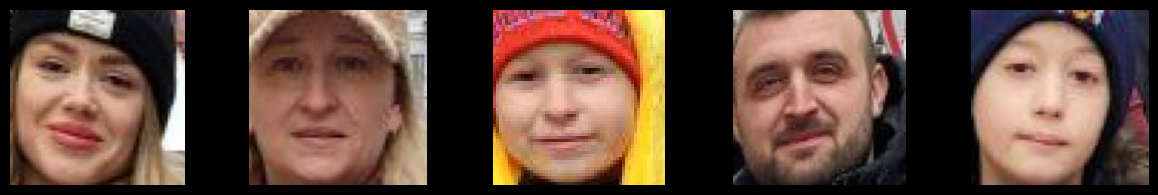

In [113]:
# Align target faces

faces_dst_agn = [recognizer.alignCrop(target, face) for face in faces_dst[1]]

plt.rcParams['figure.figsize'] = [15, 5]

for idx, faces in enumerate(zip(faces_dst_img, faces_dst_agn)):
    plt.subplot(2,len(faces_dst_agn),idx+1), plt.imshow(faces[0]), plt.axis(False)

In [114]:
# Extract features
feat_src = recognizer.feature(faces_src_agn)
feats_dst = [recognizer.feature(face) for face in faces_dst_agn]

In [115]:
scores = []
for feat_dst in feats_dst:
    score_ = recognizer.match(feat_src, feat_dst, cv2.FaceRecognizerSF_FR_COSINE)
    scores.append(score_)

scores

[0.1949160505355394,
 0.17558324714809714,
 0.5344556341187854,
 0.1480059325667753,
 0.05596654125281475]

(<Axes: >, <matplotlib.image.AxesImage at 0x21a46628550>, None)

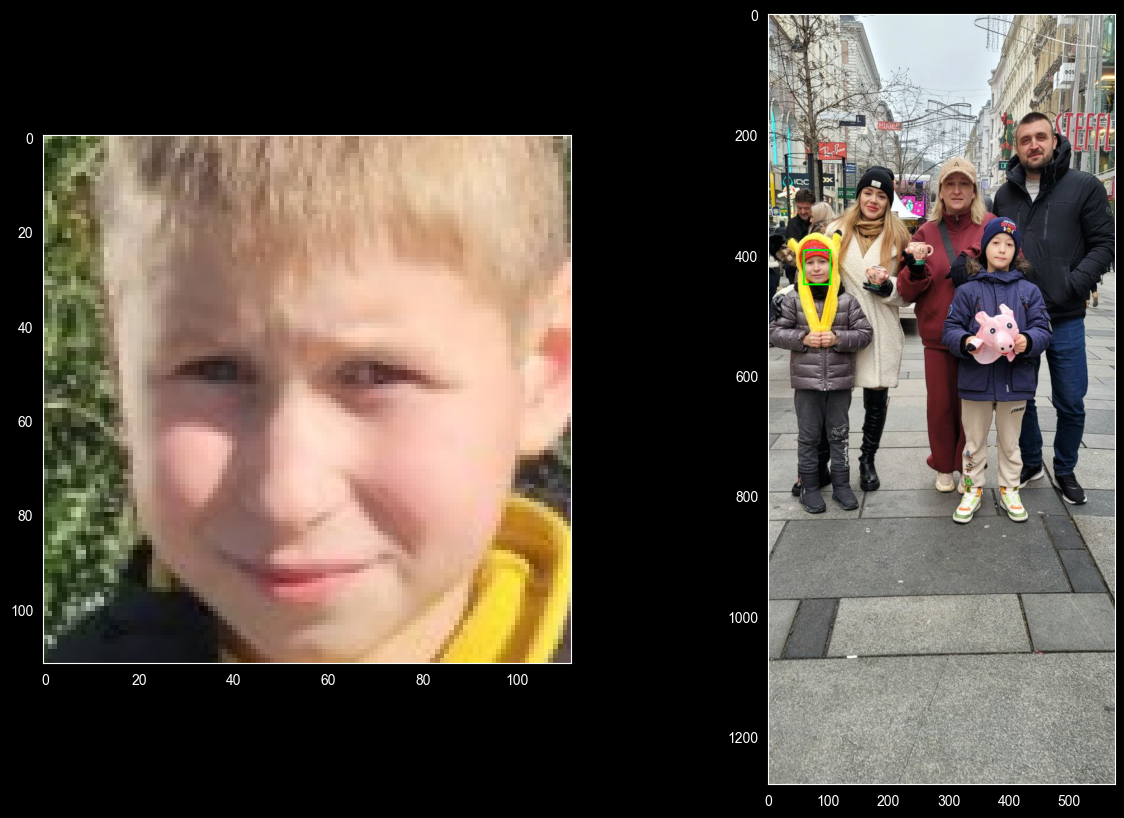

In [116]:
result = np.copy(target)
plt.rcParams['figure.figsize'] = [15, 10]

match = faces_dst[1][np.argmax(scores)]
x1, y1, w, h = match[0:4]
cv2.rectangle(result, (int(x1), int(y1)), (int(x1+w), int(y1+h)), color=(0, 255, 0), thickness=2)

plt.subplot(121), plt.imshow(faces_src_agn), plt.grid(False)
plt.subplot(122), plt.imshow(result), plt.grid(False)

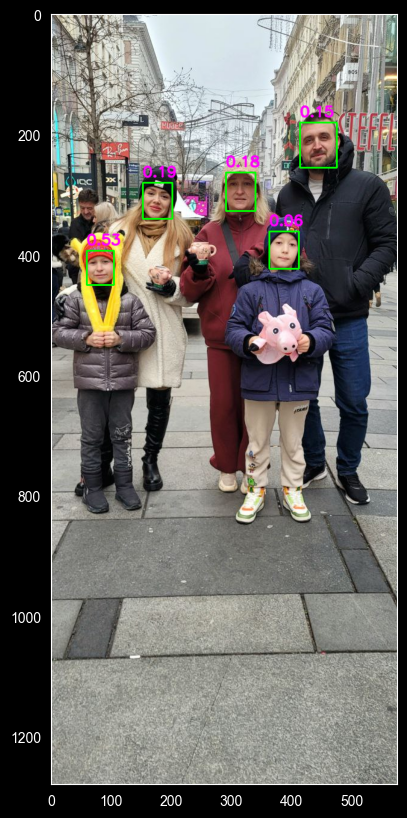

In [117]:
result = np.copy(target)

H, W = result.shape[:2]

for face, score in zip(faces_dst[1], scores):
    x1, y1, w, h = face[0:4]

    x1i, y1i = int(round(float(x1))), int(round(float(y1)))
    x2i, y2i = int(round(float(x1 + w))), int(round(float(y1 + h)))

    x1i = max(0, min(W - 1, x1i))
    y1i = max(0, min(H - 1, y1i))

    cv2.rectangle(result, (x1i, y1i), (x2i, y2i), color=(0, 255, 0), thickness=2)

    cv2.putText(
        result,
        f"{float(score):.2f}",
        (x1i, y1i - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255, 0, 255),
        2,
        lineType=cv2.LINE_AA,
    )


plt.imshow(result)
plt.grid(False)